# Distribution of extracted traits across species
Place this notebook beside `angiosperm-peatland-386-385.bhl.traits.xlsx`, or change the path below. Requires pandas, openpyxl and matplotlib.

Uses the **combined** sheet by default; switch to a source sheet for source-specific coverage. The long-form provenance sheet is not supported. Each taxon counts once per trait, regardless of repeated rows. Missing or whitespace-only cells are excluded; zero, False and recorded absences count as information. Taxon names are trimmed, not taxonomically reconciled. Zero-count traits are retained. The caption uses the actual taxon count, not the 385 from the reference figure.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [5]:
OUTPUT_DIR = Path('../adept/data/processing/output')

In [7]:
df = pd.read_excel(OUTPUT_DIR / "bhl/angiosperm-peatland-386-385.bhl.traits.xlsx", sheet_name="combined")

## Count taxa with data for each trait
You can reuse `count_trait_species(df)` with an existing wide DataFrame. Supply `trait_columns` explicitly if you have additional metadata columns.

In [8]:
METADATA_COLUMNS = {"taxon", "matched_name", "record_id", "source", "source_id", "source_url"}

def count_trait_species(frame, taxon_col="taxon", trait_columns=None):
    if taxon_col not in frame:
        raise ValueError(f"Missing column: {taxon_col}")
    if {"trait", "value"}.issubset(frame.columns):
        raise ValueError("Select a wide trait sheet, not provenance.")
    if trait_columns is None:
        trait_columns = [c for c in frame.columns
                         if c not in METADATA_COLUMNS and c != taxon_col
                         and not c.endswith("_verbatim") and not c.startswith("Unnamed:")]
    if not trait_columns:
        raise ValueError("No trait columns selected")
    taxa = frame[taxon_col].astype("string").str.strip().replace("", pd.NA)
    valid = taxa.notna()
    if not valid.any():
        raise ValueError("No taxon names")
    values = frame.loc[valid, trait_columns].replace(r"^\s*$", pd.NA, regex=True)
    # Boolean presence ensures numeric zero and False are counted.
    per_taxon = values.notna().groupby(taxa.loc[valid], sort=False).any()
    counts = per_taxon.sum().astype(int).sort_values(ascending=False, kind="stable")
    counts.index.name = "trait"
    counts.name = "species_count"
    return counts, len(per_taxon)

trait_counts, n_species = count_trait_species(df)
print(f"{n_species:,} unique taxa; {len(trait_counts)} traits")
print(trait_counts.to_string())

382 unique taxa; 80 traits
trait
habitat                          380
habit                            380
clonality                        380
perennial organ                  379
life form                        367
leaf min. length [cm]            327
leaf max. length [cm]            327
leaf shape                       309
leaf apex                        303
plant min. height [m]            302
plant max. height [m]            302
inflorescence arrangement        276
indumentum                       264
leaf min. width [cm]             264
leaf max. width [cm]             264
leaf margin                      250
leaf architecture                204
leaf base                        192
flower colour                    185
ploidy level (2n)                176
seed min. length [mm]            174
seed max. length [mm]            174
dispersal mode                   165
fruit type                       162
fruit structure                  157
fruit dehiscence                 155
stame

## Plot and export
Adjust width, row height, font size or colour below. Saves a 300-dpi PNG, a vector PDF and a CSV of counts. The caption counts all taxa in the selected sheet, including any without recorded traits.

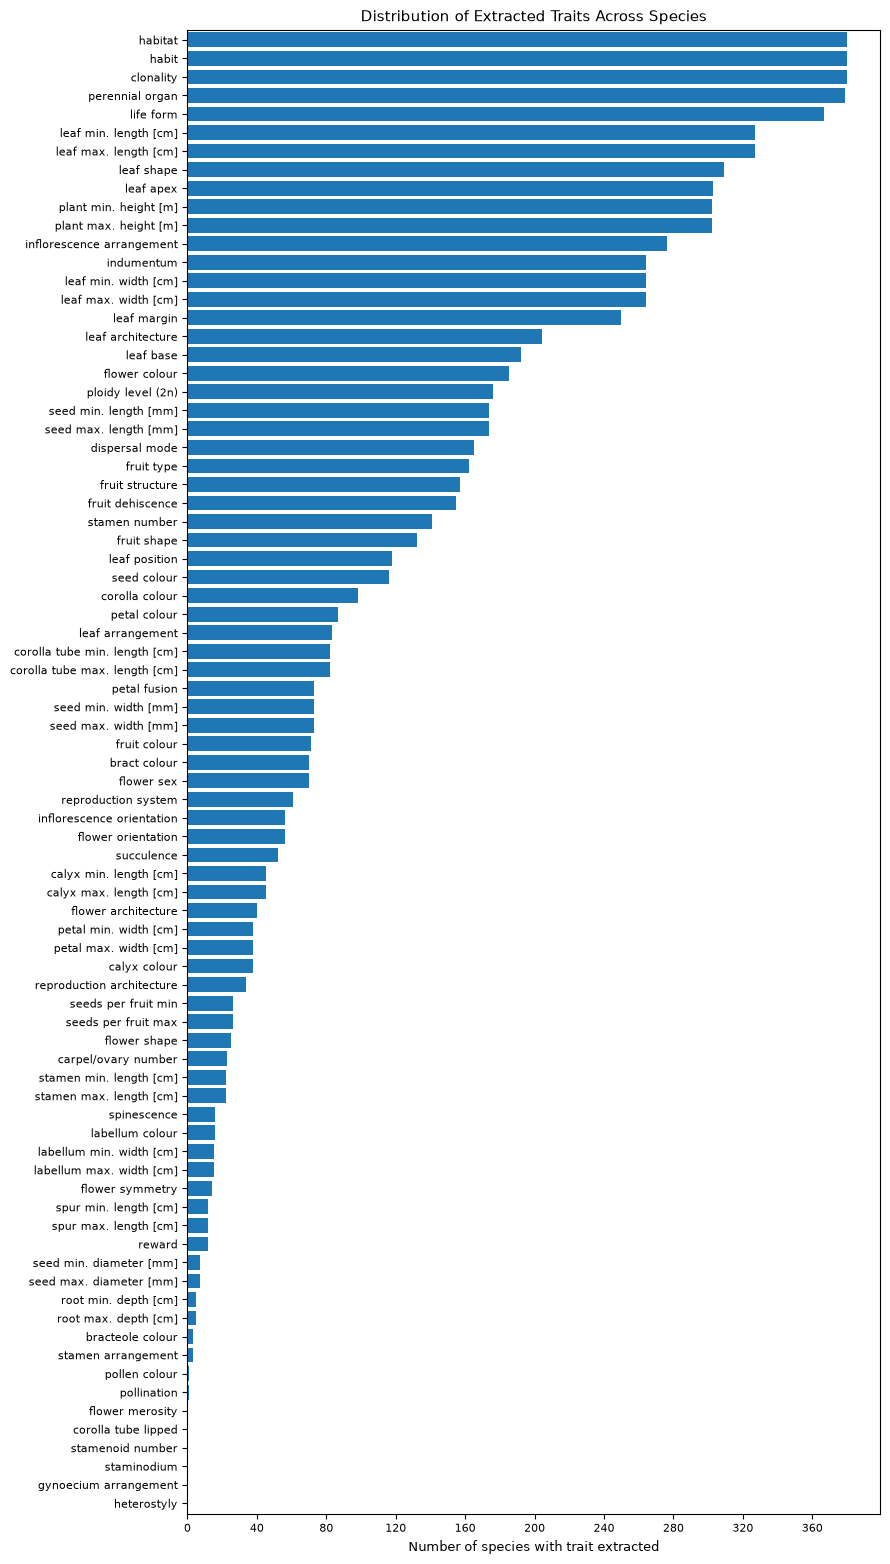

In [12]:
FIGURE_WIDTH = 9
ROW_HEIGHT = 0.19
FONT_SIZE = 8
BAR_COLOUR = "#1f77b4"
SHOW_CAPTION = True

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, max(5, len(trait_counts) * ROW_HEIGHT + 1.2)))
ax.barh(trait_counts.index, trait_counts.values, color=BAR_COLOUR, height=0.8)
ax.invert_yaxis()
ax.margins(y=0.002)
ax.set_xlim(0, max(1, trait_counts.max() * 1.05))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("Distribution of Extracted Traits Across Species", fontsize=11)
ax.set_xlabel("Number of species with trait extracted", fontsize=9)
ax.tick_params(axis="both", labelsize=FONT_SIZE)
fig.tight_layout(rect=(0, 0.04 if SHOW_CAPTION else 0, 1, 1))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(f"trait_distribution_{SHEET_NAME}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"trait_distribution_{SHEET_NAME}.pdf", bbox_inches="tight")
trait_counts.to_csv(f"trait_distribution_{SHEET_NAME}.csv")
plt.show()